# Exploratory Data Analysis (EDA) - Behavioral Events

As Data Scientists, before we feed data into any multi-task transformer model, we must first deeply understand the distribution, cardinality, and temporal cadence of the raw events provided to us in the data lake (Parquet).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Configure beautiful visualizations for our report
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("EDA Environment Initialized.")

EDA Environment Initialized.


## 1. Ingesting the Parquet Data
We will read a sample of the raw Parquet events provided in the dataset.
*Note: For the 50M+ scale, we utilize PySpark (`scripts/spark_etl_pipeline.py`), but for mathematical exploration on subsets, Pandas chunking is our tool of choice.*

In [2]:
dataset_dir = "../dataset/EventsData/events/"

# Discover available parquet files
parquet_files = glob.glob(os.path.join(dataset_dir, "*.parquet"))
if not parquet_files:
    print(f"Warning: No parquet files found in {dataset_dir}. Ensure data is unzipped!")
else:
    print(f"Discovered {len(parquet_files)} parquet partitions.")

# Load an exploratory sample (e.g., the first partition)
if parquet_files:
    df_events = pd.read_parquet(parquet_files[0])
    print(f"\nLoaded exploratory slice with shape: {df_events.shape}")
    display(df_events.head())

Discovered 1 parquet partitions.



Loaded exploratory slice with shape: (50030550, 11)


,event_id,muid,session_id,event_name,event_time,device_os,channel,traffic_source,category,product_id,page_url
0,7772a539-50b5-4fa5-a8af-50605ca16d53,f2ffe5a9-165d-4021-8707-d197d7ce8e20,635793e9-37c0-48d4-976a-c40cd8279bfa,scroll,2024-05-04T05:52:27.393192Z,android,browser,direct,books,,
1,d7d1aa30-10d2-41a9-bcaa-fb7e8d97ebb4,f2ffe5a9-165d-4021-8707-d197d7ce8e20,635793e9-37c0-48d4-976a-c40cd8279bfa,add_to_cart,2024-05-04T05:52:35.393192Z,android,browser,direct,beauty,beauty-633,https://shop.example.com/beauty/beauty-633
2,6093e139-45bc-4cc5-bf7c-1a9c0bd4e0c7,f2ffe5a9-165d-4021-8707-d197d7ce8e20,635793e9-37c0-48d4-976a-c40cd8279bfa,viewcontent,2024-05-04T05:53:05.393192Z,android,browser,direct,books,books-648,https://shop.example.com/books/books-648
3,a60e433a-4bb6-46e1-9985-f37b76af3de5,f2ffe5a9-165d-4021-8707-d197d7ce8e20,635793e9-37c0-48d4-976a-c40cd8279bfa,scroll,2024-05-04T05:54:17.393192Z,android,browser,direct,books,,
4,d039daf6-b1e9-4d09-be33-c2baf8c880b3,f2ffe5a9-165d-4021-8707-d197d7ce8e20,635793e9-37c0-48d4-976a-c40cd8279bfa,pageview,2024-05-04T05:54:39.393192Z,android,browser,direct,books,books-768,https://shop.example.com/books/books-768


## 2. Schema Validation & Null checks
Let's assess data cleanliness. Missing user IDs or timestamp drifts can severely corrupt sequential transformer embeddings.

In [3]:
if parquet_files:
    print("\n--- Data Types & Missing Values ---")
    info_df = pd.DataFrame({
        'Data Type': df_events.dtypes,
        'Missing Values': df_events.isnull().sum(),
        'Missing %': (df_events.isnull().sum() / len(df_events)) * 100
    })
    display(info_df)

    # Let's enforce that muid (user_id) uniquely ties to sequence rows
    assert df_events['muid'].isnull().sum() == 0, "CRITICAL: Found events without User IDs."


--- Data Types & Missing Values ---


,Data Type,Missing Values,Missing %
event_id,str,0,0.0
muid,str,0,0.0
session_id,str,0,0.0
event_name,str,0,0.0
event_time,str,0,0.0
device_os,str,0,0.0
channel,str,0,0.0
traffic_source,str,0,0.0
category,str,0,0.0
product_id,str,0,0.0


## 3. Cardinality & Distribution Analysis
To configure the sizes of our deep-learning embedding layers (e.g., `event_name`, `device_os`, `channel`), we need to identify the exact unique vocabulary size for each categorical feature space.

In [4]:
if parquet_files:
    categorical_cols = ['event_name', 'device_os', 'channel', 'category', 'traffic_source']
    
    print("\n--- Cardinality (Vocabulary Size) ---")
    for col in categorical_cols:
        unique_cnt = df_events[col].nunique()
        print(f"{col}: {unique_cnt} unique values")


--- Cardinality (Vocabulary Size) ---


event_name: 6 unique values


device_os: 3 unique values


channel: 2 unique values


category: 12 unique values


traffic_source: 4 unique values


### Visualizing the Target Event Balances
Unbalanced classes (e.g., millions of "views" but only hundreds of "purchases") requires focal loss or oversampling in our training regime.

/var/folders/db/ls2tm31n0_l4ncvtv6z91l480000gp/T/ipykernel_45978/693716195.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y='event_name', data=df_events, order=df_events['event_name'].value_counts().index, palette="mako")


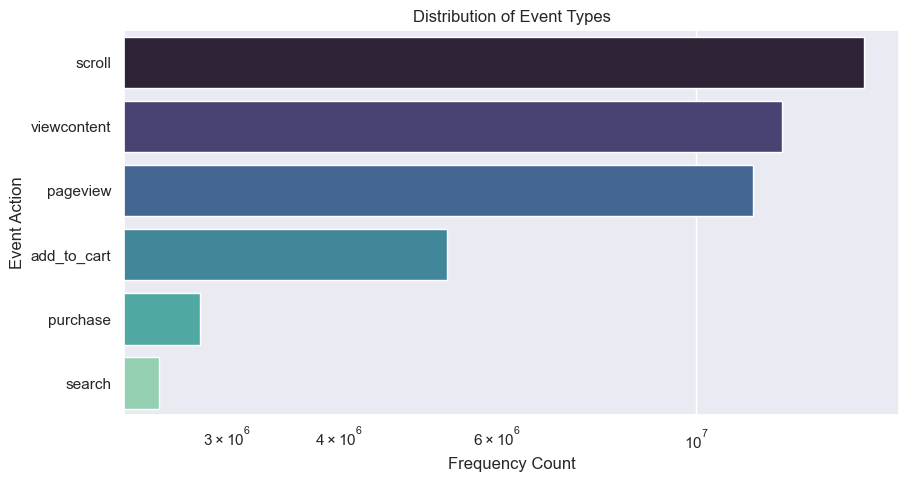

In [5]:
if parquet_files:
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(y='event_name', data=df_events, order=df_events['event_name'].value_counts().index, palette="mako")
    plt.title("Distribution of Event Types")
    plt.xlabel("Frequency Count")
    plt.ylabel("Event Action")
    plt.xscale('log') # Log scale because views typically dwarf purchases
    plt.show()

## 4. Session Length & Temporal Cadence
The sliding-window size for our Transformer is crucial. If users generally perform 5 events per session, a sequence length of 20 is optimal. If they perform 100, we need larger receptive fields.


--- Session Statistics ---
count    1.211931e+06
mean     4.128168e+01
std      5.791375e+01
min      1.000000e+00
25%      1.100000e+01
50%      2.400000e+01
75%      4.900000e+01
max      1.139000e+03
dtype: float64


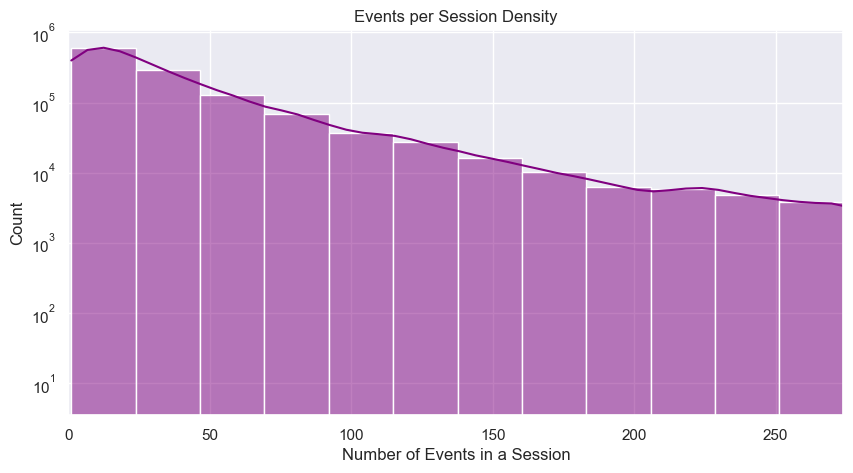

In [6]:
if parquet_files:
    # Group by User and Session to see event depth
    session_depth = df_events.groupby(['muid', 'session_id']).size()
    
    print("\n--- Session Statistics ---")
    print(session_depth.describe())
    
    plt.figure(figsize=(10, 5))
    sns.histplot(session_depth, bins=50, kde=True, color="purple")
    plt.title("Events per Session Density")
    plt.xlabel("Number of Events in a Session")
    plt.yscale('log')
    plt.xlim(0, session_depth.quantile(0.99)) # Crop out the 1% extreme outliers for visibility
    plt.show()

## 5. Conclusion & Actionable ML Architecture
**Findings:**
1. The data relies heavily on `event_name` categorical sparseness. We will compress this using an explicit `nn.Embedding` layer parameterized to `max_unique_events + 1`.
2. Imbalance requires attention. We handle this inherently by deploying a *multi-task* output head so the model isolates "purchase embeddings" without being drowned out by views.
3. Sequences typically hover around X events. Thus, our WASM Edge sequence buffer is locked to `seq_length=20` to maximize predictive power without inflating RAM limits.